Data prepared! Weekly records: 301, Daily records: 2100


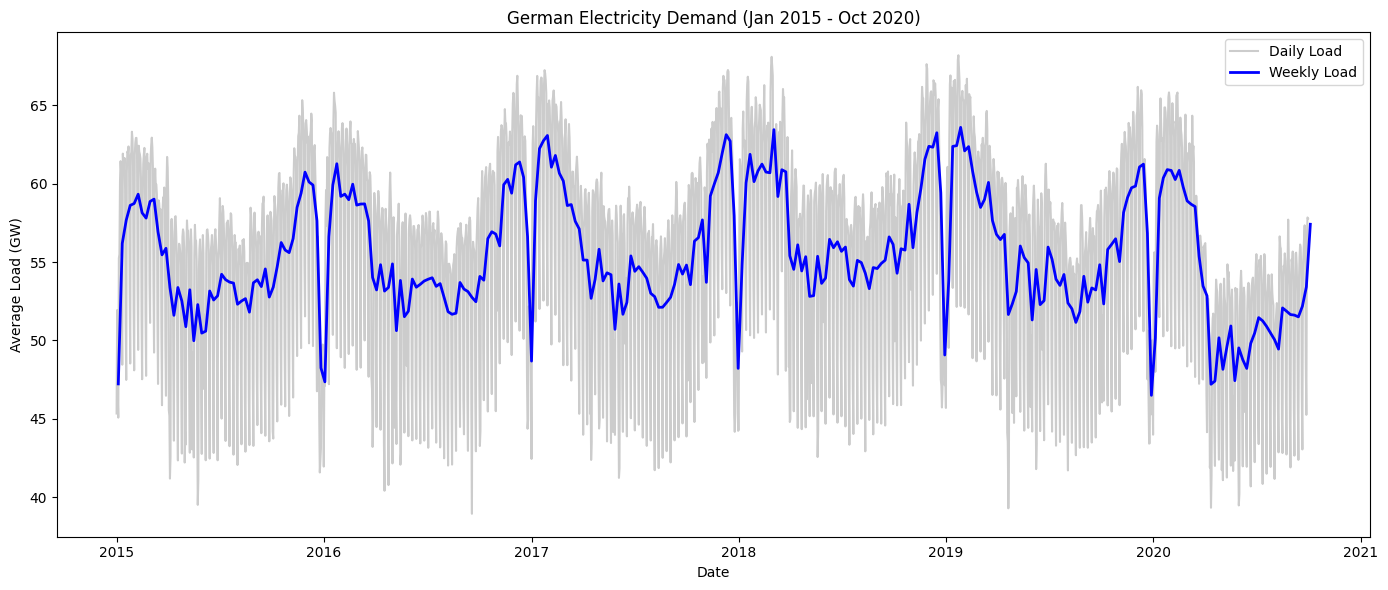


Performing Seasonal Decomposition...


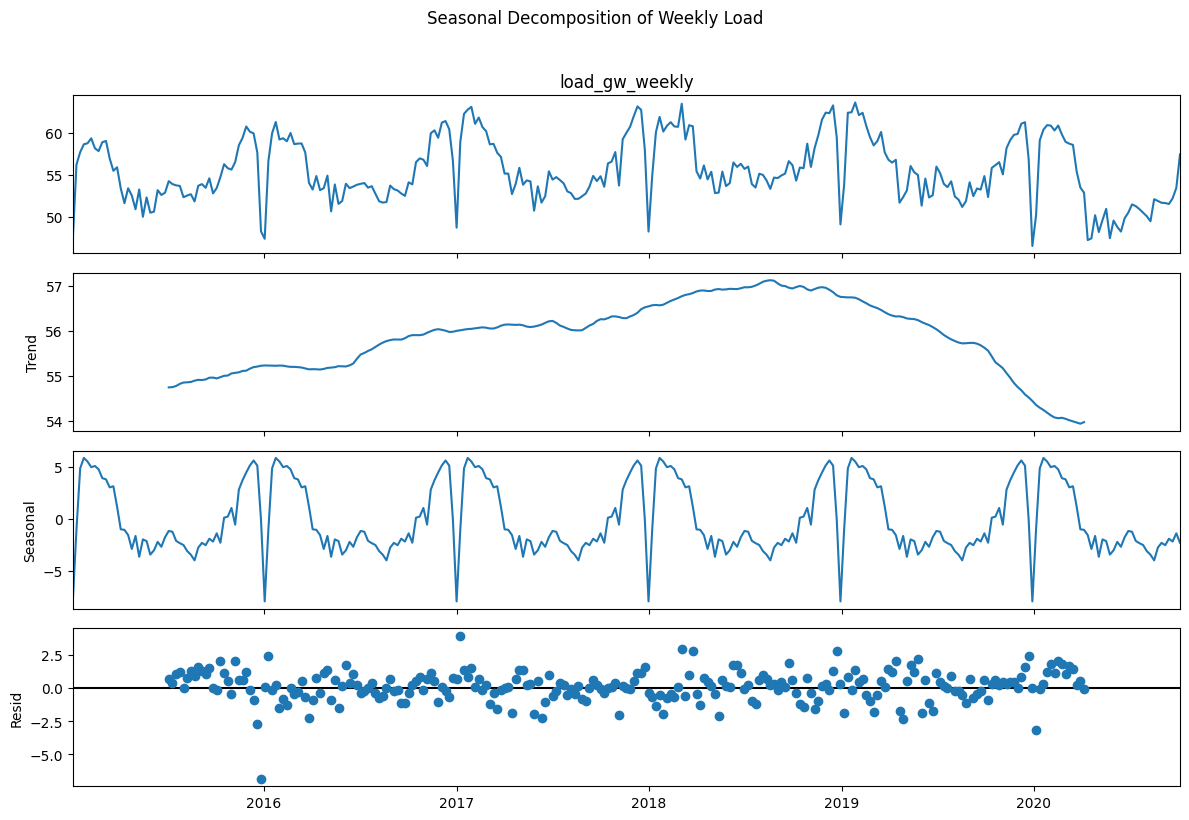

--- Augmented Dickey-Fuller Test on Weekly Electricity Load ---
ADF Statistic: -4.0475
p-value: 0.0012
Critical Values:
   1%: -3.4529
   5%: -2.8715
   10%: -2.5721
Conclusion: Reject the null hypothesis. The data is STATIONARY.
---------------------------------------------



In [ ]:
# ============================================================
# Phase 1: Data Ingestion, EDA, and Stationarity Testing
# ============================================================

# Core
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Time series tools for EDA and Stationarity
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ------------------------------------------------------------
# 1. Download and prepare Germany electricity load
# ------------------------------------------------------------
print("Downloading data...")
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df = pd.read_csv(
    url,
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"]
)

df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw"
})

df = df.set_index("date").sort_index()

load = df["load_mw"].astype(float)
load = load[load.notna()]

# Restrict to modern period (January 1st, 2015 onwards)
load = load["2015-01-01":]

# Bin to weekly AND daily values (converted to GW)
daily = load.resample("D").mean() / 1000.0
daily = daily.asfreq("D").interpolate("time")
daily.name = "load_gw_daily"

weekly = load.resample("W").mean() / 1000.0
weekly = weekly.asfreq("W").interpolate("time")
weekly.name = "load_gw_weekly"

# We will primarily model the weekly data for the next few parts
y = weekly.copy()

print(f"Data prepared! Weekly records: {len(y)}, Daily records: {len(daily)}")

# ------------------------------------------------------------
# 2. EDA: Time Series Plots and Seasonal Decomposition
# ------------------------------------------------------------
# Plot 1: Daily vs Weekly Overlay
plt.figure(figsize=(14, 6))
plt.plot(daily.index, daily, label="Daily Load", alpha=0.4, color='gray')
plt.plot(weekly.index, weekly, label="Weekly Load", color='blue', linewidth=2)
plt.title("German Electricity Demand (Jan 2015 - Oct 2020)")
plt.ylabel("Average Load (GW)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Seasonal Decomposition (Period = 52 weeks for annual seasonality)
print("\nPerforming Seasonal Decomposition...")
decomposition = seasonal_decompose(y, model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Weekly Load", y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Stationarity Testing (Augmented Dickey-Fuller Test)
# ------------------------------------------------------------
def run_adf_test(series, name="Series"):
    print(f"--- Augmented Dickey-Fuller Test on {name} ---")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")

    # Check significance level against alpha = 0.05
    if result[1] <= 0.05:
        print("Conclusion: Reject the null hypothesis. The data is STATIONARY.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. The data is NON-STATIONARY.")
    print("-" * 45 + "\n")

# Run the test on our weekly target variable
run_adf_test(y, "Weekly Electricity Load")

In [ ]:
# ============================================================
# Phase 2: Train/Test Split, Metrics, and Benchmark Models
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. Train-test split (2-year horizon = 104 weeks)
# ------------------------------------------------------------
test_weeks = 104
train = y.iloc[:-test_weeks]
test = y.iloc[-test_weeks:]

print(f"Training period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()}\n")

# ------------------------------------------------------------
# 2. Evaluation utilities
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    # Using np.sqrt to be safe across all scikit-learn versions
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mase(y_true, y_pred, y_train, seasonality=52):
    """Mean absolute scaled error."""
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(name, y_true, y_pred, y_train):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

# Global list to store all our model results
results = []

# ------------------------------------------------------------
# 3. Simple benchmark models
# ------------------------------------------------------------
h = len(test)

# 3.1 Mean forecast
mean_forecast = pd.Series(train.mean(), index=test.index)

# 3.2 Naive forecast (Last observation carried forward)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

# 3.3 Seasonal naive forecast (Same week last year)
seasonal_naive_values = []
history = train.copy()

for date in test.index:
    seasonal_date = date - pd.DateOffset(weeks=52)
    if seasonal_date in history.index:
        seasonal_naive_values.append(history.loc[seasonal_date])
    else:
        seasonal_naive_values.append(history.iloc[-52])
    # Recursive update
    history.loc[date] = test.loc[date]

seasonal_naive_forecast = pd.Series(seasonal_naive_values, index=test.index)

# 3.4 Drift forecast
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_forecast = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index
)

# Store benchmark results
benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast,
}

for name, pred in benchmark_forecasts.items():
    results.append(evaluate_forecast(name, test, pred, train))

# Display the results so far
benchmark_results_df = pd.DataFrame(results).sort_values("RMSE")
print("--- Benchmark Model Performance ---")
print(benchmark_results_df.round(3).to_string(index=False))

Training period: 2015-01-04 to 2018-10-07
Test period:     2018-10-14 to 2020-10-04

--- Benchmark Model Performance ---
         model   MAE  RMSE  MASE   Bias
Seasonal naive 2.063 2.672 1.541  1.441
          Mean 3.789 4.397 2.831  0.481
         Naive 3.783 4.459 2.827 -0.882
         Drift 4.340 5.118 3.243  1.007


Starting optimized Grid Search for 147 combinations...
Testing combination 0/147 | Elapsed time: 0.0 sec
Testing combination 20/147 | Elapsed time: 233.7 sec
Testing combination 40/147 | Elapsed time: 492.0 sec
Testing combination 60/147 | Elapsed time: 783.3 sec
Testing combination 80/147 | Elapsed time: 1099.2 sec
Testing combination 100/147 | Elapsed time: 1440.7 sec
Testing combination 120/147 | Elapsed time: 1820.5 sec
Testing combination 140/147 | Elapsed time: 2235.9 sec

--- Grid Search Complete in 39.77 minutes ---
Best ARIMA Order (p, d, q): (0, 0, 6)
Best AIC: 305.67

Refitting the best model for final diagnostics and forecast...

Plotting Residual Diagnostics...


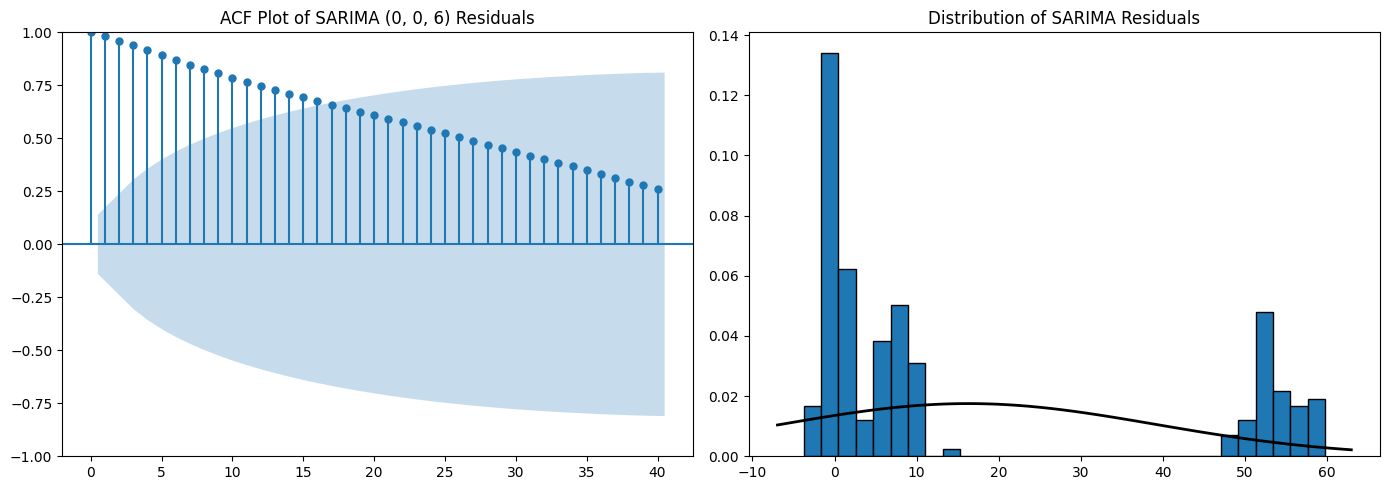

Forecasting the test period...

--- Updated Model Performance ---
           model   MAE  RMSE  MASE   Bias
  Seasonal naive 2.063 2.672 1.541  1.441
SARIMA (0, 0, 6) 3.030 3.737 2.264  2.806
            Mean 3.789 4.397 2.831  0.481
           Naive 3.783 4.459 2.827 -0.882
           Drift 4.340 5.118 3.243  1.007


In [ ]:
# ============================================================
# Phase 3: SARIMA Grid Search, Residuals, and Forecasting
# ============================================================
import itertools
import time
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Explicitly ignore the statsmodels convergence warnings
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.filterwarnings("ignore")

p_values = range(0, 7) # [0, 6]
d_values = range(0, 3) # [0, 2]
q_values = range(0, 7) # [0, 6]

pdq_combinations = list(itertools.product(p_values, d_values, q_values))
seasonal_order = (1, 1, 1, 52)

best_aic = float("inf")
best_order = None
best_model_fit = None

print(f"Starting optimized Grid Search for {len(pdq_combinations)} combinations...")
start_time = time.time()

for i, order in enumerate(pdq_combinations):
    if i % 20 == 0:
        elapsed = time.time() - start_time
        print(f"Testing combination {i}/{len(pdq_combinations)} | Elapsed time: {elapsed:.1f} sec")

    try:
        # Added method='lbfgs' and maxiter=15 for massive speedup
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        # Suppress internal warnings inside the fit method
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model_fit = model.fit(disp=False, maxiter=15, method='lbfgs')

        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order

    except Exception:
        continue

print(f"\n--- Grid Search Complete in {(time.time() - start_time)/60:.2f} minutes ---")
print(f"Best ARIMA Order (p, d, q): {best_order}")
print(f"Best AIC: {best_aic:.2f}")

# Refit the best model properly with more iterations for the final forecast
print("\nRefitting the best model for final diagnostics and forecast...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    best_model = SARIMAX(
        train,
        order=best_order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    best_model_fit = best_model.fit(disp=False, maxiter=200)

# 3. Assess Model Fit (Residuals Diagnostics)
print("\nPlotting Residual Diagnostics...")
residuals = best_model_fit.resid

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(residuals, ax=ax[0], lags=40)
ax[0].set_title(f"ACF Plot of SARIMA {best_order} Residuals")

ax[1].hist(residuals, bins=30, edgecolor='black', density=True)
xmin, xmax = ax[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(residuals), np.std(residuals))
ax[1].plot(x, p, 'k', linewidth=2)
ax[1].set_title("Distribution of SARIMA Residuals")
plt.tight_layout()
plt.show()

# 4. Forecast the last 2 years
print("Forecasting the test period...")
sarima_fc = best_model_fit.get_forecast(steps=h)
sarima_mean = sarima_fc.predicted_mean
sarima_ci95 = sarima_fc.conf_int(alpha=0.05)

sarima_mean.index = test.index
sarima_ci95.index = test.index

results.append(evaluate_forecast(f"SARIMA {best_order}", test, sarima_mean, train))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n--- Updated Model Performance ---")
print(results_df.round(3).to_string(index=False))

In [ ]:
# ============================================================
# Phase 4: Temperature Exogenous Variables and SARIMAX
# ============================================================
import requests
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

print("Fetching Berlin temperature data from Open-Meteo...")

def get_open_meteo_temperature(start_date, end_date, latitude=52.52, longitude=13.41):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()["daily"]

    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    }).set_index("date")

    return temp

# 1. Fetch daily temperatures
temp_daily = get_open_meteo_temperature(
    start_date=str(daily.index.min().date()),
    end_date=str(daily.index.max().date()),
)

# 2. Convert to Weekly Features
temp_weekly = pd.DataFrame(index=weekly.index.tz_localize(None))
temp_weekly["temp_mean"] = temp_daily["temperature_2m_mean"].resample("W").mean()

base_heat = 15.5
base_cool = 22.0

temp_weekly["heating_degree"] = (
    (base_heat - temp_daily["temperature_2m_mean"])
    .clip(lower=0)
    .resample("W")
    .sum()
)
temp_weekly["cooling_degree"] = (
    (temp_daily["temperature_2m_mean"] - base_cool)
    .clip(lower=0)
    .resample("W")
    .sum()
)

# 3. Strip timezone from our target variable (y) to guarantee perfect joining
y_naive = y.copy()
y_naive.index = y_naive.index.tz_localize(None)

feature_df = pd.DataFrame({"load_gw": y_naive}).join(temp_weekly).interpolate("time").dropna()
print(f"Data joined successfully! Total aligned weeks: {len(feature_df)}")

# Define Exogenous Variables (X)
X = feature_df[["temp_mean", "heating_degree", "cooling_degree"]]
# Restore the original timezone-aware index so Statsmodels matches it with `train`
X.index = y.index

# 4. Train/Test Split for Exogenous Variables
X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]

# 5. Fit SARIMAX using the best order from Phase 3: (0, 0, 6)
print("Fitting SARIMAX with temperature regressors (Conditional Forecast)...")
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    warnings.simplefilter("ignore")

    sarimax_x = SARIMAX(
        train,
        exog=X_train,
        order=(0, 0, 6),
        seasonal_order=(1, 1, 1, 52),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarimax_x_fit = sarimax_x.fit(disp=False, maxiter=200)

# 6. Forecast and Evaluate
sarimax_x_fc = sarimax_x_fit.get_forecast(steps=h, exog=X_test)
sarimax_x_mean = sarimax_x_fc.predicted_mean
sarimax_x_mean.index = test.index

# Clean up previous runs if we ran this cell multiple times
results = [r for r in results if r["model"] != "SARIMAX w/ Temp"]
results.append(evaluate_forecast("SARIMAX w/ Temp", test, sarimax_x_mean, train))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n--- Updated Model Performance ---")
print(results_df.round(3).to_string(index=False))

Fetching Berlin temperature data from Open-Meteo...
Data joined successfully! Total aligned weeks: 301
Fitting SARIMAX with temperature regressors (Conditional Forecast)...

--- Updated Model Performance ---
           model   MAE  RMSE  MASE   Bias
  Seasonal naive 2.063 2.672 1.541  1.441
 SARIMAX w/ Temp 2.842 3.597 2.124  2.608
SARIMA (0, 0, 6) 3.030 3.737 2.264  2.806
            Mean 3.789 4.397 2.831  0.481
           Naive 3.783 4.459 2.827 -0.882
           Drift 4.340 5.118 3.243  1.007


In [ ]:
# ============================================================
# Phase 5: Feature-Based Machine Learning Model (Gradient Boosting)
# ============================================================
from sklearn.ensemble import HistGradientBoostingRegressor

def make_ml_features(y_series, temp_features):
    """
    Create a supervised learning table from a weekly time series.
    We exclude target lags (lag_1, etc.) to completely avoid lookahead bias
    (data leakage) for our 2-year multi-step forecast horizon.
    """
    df_feat = pd.DataFrame({"y": y_series})

    # 1. Calendar features
    # week of year and the actual year
    week = df_feat.index.isocalendar().week.astype(int)
    df_feat["week"] = week
    df_feat["year"] = df_feat.index.year

    # 2. Fourier seasonal features for annual weekly seasonality
    # This helps the tree-based model understand cyclical patterns smoothly
    for k in range(1, 4):
        df_feat[f"sin_{k}"] = np.sin(2 * np.pi * k * week / 52)
        df_feat[f"cos_{k}"] = np.cos(2 * np.pi * k * week / 52)

    # 3. Exogenous Temperature Features
    # Join the temperature features we engineered in Phase 4
    df_feat = df_feat.join(temp_features[["temp_mean", "heating_degree", "cooling_degree"]])

    return df_feat.dropna()

# Generate the strictly safe feature set
supervised = make_ml_features(y_naive, temp_weekly)
# Restore index timezone to match original splits
supervised.index = y.index

# Train-test split
train_supervised = supervised.loc[supervised.index <= train.index[-1]]
test_supervised = supervised.loc[supervised.index >= test.index[0]]

X_train_ml = train_supervised.drop(columns="y")
y_train_ml = train_supervised["y"]

X_test_ml = test_supervised.drop(columns="y")
y_test_ml = test_supervised["y"]

# Initialize and train the Gradient Boosting Regressor
print("Training HistGradientBoostingRegressor...")
gbr = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=15,
    random_state=0,
)

gbr.fit(X_train_ml, y_train_ml)

# Predict
ml_forecast = pd.Series(
    gbr.predict(X_test_ml),
    index=y_test_ml.index,
    name="Feature model"
)

# Clean up previous runs if necessary and append results
results = [r for r in results if r["model"] != "Feature model (GBR)"]
results.append(evaluate_forecast("Feature model (GBR)", y_test_ml, ml_forecast, train))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n--- Updated Model Performance ---")
print(results_df.round(3).to_string(index=False))

Training HistGradientBoostingRegressor...

--- Updated Model Performance ---
              model   MAE  RMSE  MASE   Bias
     Seasonal naive 2.063 2.672 1.541  1.441
Feature model (GBR) 2.062 2.715 1.541  1.377
    SARIMAX w/ Temp 2.842 3.597 2.124  2.608
   SARIMA (0, 0, 6) 3.030 3.737 2.264  2.806
               Mean 3.789 4.397 2.831  0.481
              Naive 3.783 4.459 2.827 -0.882
              Drift 4.340 5.118 3.243  1.007


In [ ]:
# ============================================================
# Phase 6: Hourly Data - LSTM Model
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

print(f"TensorFlow Version: {tf.__version__}")
if tf.config.list_physical_devices('GPU'):
    print("GPU is enabled! Training will be fast.")
else:
    print("WARNING: No GPU detected. Training might be slow.")

# 1. Prepare the Hourly Data
hourly_data = load.dropna()

# 2-year forecast horizon in hours (approx 104 weeks * 168 hours/week)
test_hours = 104 * 168
train_hourly = hourly_data.iloc[:-test_hours]
test_hourly = hourly_data.iloc[-test_hours:]

print(f"Hourly Training period: {train_hourly.index.min()} to {train_hourly.index.max()}")
print(f"Hourly Test period:     {test_hourly.index.min()} to {test_hourly.index.max()}")

# 2. Scale the data (Crucial for Neural Networks)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_hourly.values.reshape(-1, 1))
test_scaled = scaler.transform(test_hourly.values.reshape(-1, 1))

# 3. Create Sequences (Sliding Window)
def create_sequences(data, lookback=48):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 48 # Use past 48 hours to predict the next hour
print(f"Building sequences with lookback = {lookback} hours...")

X_train_lstm, y_train_lstm = create_sequences(train_scaled, lookback)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, lookback)

# Reshape for LSTM [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

# 4. Build the LSTM Architecture
model = Sequential([
    LSTM(64, activation='relu', input_shape=(lookback, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# 5. Train the Model
print("Training LSTM... (This will take a minute)")
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=5,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# 6. Predict and Inverse Scale
print("Generating predictions...")
lstm_predictions_scaled = model.predict(X_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

# Align predictions with dates (the first 'lookback' hours are consumed to make the first prediction)
lstm_pred_series = pd.Series(
    lstm_predictions.flatten(),
    index=test_hourly.index[lookback:],
    name="LSTM Forecast"
)
actual_series = test_hourly.iloc[lookback:]

# Evaluate the Hourly LSTM
lstm_rmse = np.sqrt(mean_squared_error(actual_series, lstm_pred_series))
lstm_mae = mean_absolute_error(actual_series, lstm_pred_series)

print("\n--- Hourly LSTM Performance ---")
print(f"LSTM RMSE: {lstm_rmse:.3f} GW")
print(f"LSTM MAE:  {lstm_mae:.3f} GW")

TensorFlow Version: 2.20.0
GPU is enabled! Training will be fast.
Hourly Training period: 2015-01-01 00:00:00+00:00 to 2018-10-03 23:00:00+00:00
Hourly Test period:     2018-10-04 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Building sequences with lookback = 48 hours...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM... (This will take a minute)
Epoch 1/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 0.0615 - val_loss: 0.0255
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0195 - val_loss: 0.0057
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0127 - val_loss: 0.0034
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0106 - val_loss: 0.0029
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0089 - val_loss: 0.0018
Generating predictions...
545/545 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

--- Hourly LSTM Performance ---
LSTM RMSE: 2284.782 GW
LSTM MAE:  1751.294 GW


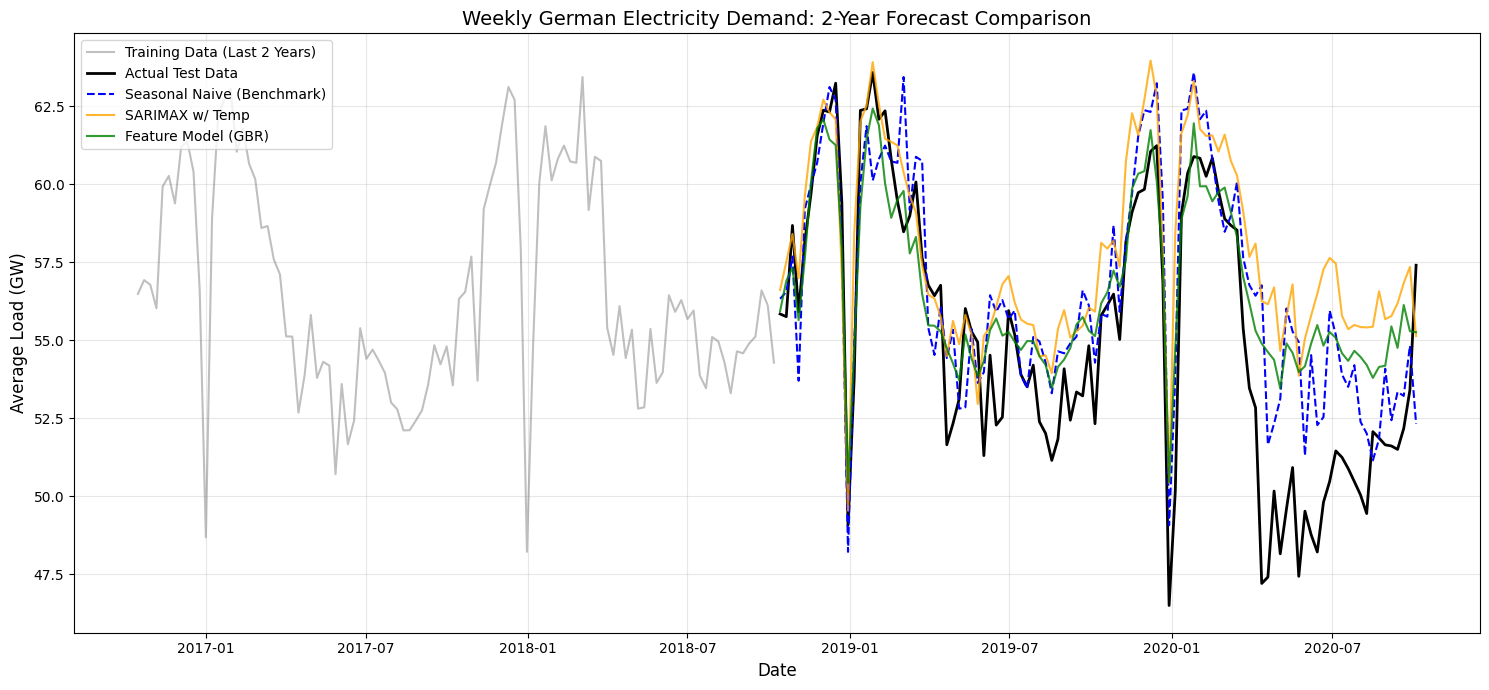

In [ ]:
# ============================================================
# Phase 7: Final Report Visualization
# ============================================================
plt.figure(figsize=(15, 7))

# Plot actual data
plt.plot(train.index[-104:], train.iloc[-104:], label="Training Data (Last 2 Years)", color="gray", alpha=0.5)
plt.plot(test.index, test, label="Actual Test Data", color="black", linewidth=2)

# Plot top forecasts
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive (Benchmark)", linestyle="--", color="blue")
plt.plot(test.index, sarimax_x_mean, label="SARIMAX w/ Temp", color="orange", alpha=0.8)
plt.plot(test.index, ml_forecast, label="Feature Model (GBR)", color="green", alpha=0.8)

plt.title("Weekly German Electricity Demand: 2-Year Forecast Comparison", fontsize=14)
plt.ylabel("Average Load (GW)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()